In [13]:
import numpy as np
import torch
import random

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Data generation
from src.data_generation.representation_bias_world import simulate_representation_bias_world

# Preprocessing
from src.training.preprocessing import split_data, scale_data

# Logistic Regression
from src.training.train_lr import train_logistic_regression

# MLP + training curves
from src.training.train_mlp import train_mlp_model, plot

# Fairness metrics
from src.metrics.fairness import fairness_by_group, equal_opportunity_diff

print("Imports OK")


Imports OK


In [15]:
# Create dataset with a minority group representing only 10% of population
df = simulate_representation_bias_world(n_samples=10000, minority_frac=0.10, seed=SEED)

df.head()


,race,gender,age,glucose_measured,hba1c_measured,diabetes_label
0,0,0,67.175802,80.537222,4.812040,0
1,1,0,66.259780,88.842214,5.118962,0
2,1,0,46.984864,106.744255,4.854207,0
3,0,1,59.680296,91.709544,4.898011,0
4,1,0,52.566852,153.419783,6.371632,1


In [16]:
df["race"].value_counts(normalize=True)


race
0    0.702392
1    0.281049
2    0.016559
Name: proportion, dtype: float64

In [17]:
features = ["glucose_measured", "hba1c_measured", "age"]
target = "diabetes_label"

X_train, X_test, y_train, y_test = split_data(df, features, target)
X_train_s, X_test_s, scaler = scale_data(X_train, X_test)

print("Train size:", len(X_train))
print("Test size:", len(X_test))
print("Prevalence:", y_train.mean())


Train size: 6956
Test size: 1740
Prevalence: 0.1960897067280046


In [18]:
lr_results = train_logistic_regression(
    X_train_s, y_train,
    X_test_s, y_test
)

lr_results


{'model': LogisticRegression(max_iter=2000),
 'pred': array([0, 0, 1, ..., 1, 0, 1], shape=(1740,)),
 'probs': array([1.89321480e-03, 5.49735846e-06, 9.99999823e-01, ...,
        9.99851961e-01, 4.72805295e-04, 9.99947317e-01], shape=(1740,)),
 'accuracy': 0.9994252873563219,
 'AUROC': 0.9999854553010233}

Epoch 1/20: train_loss=0.2000, train_acc=93.88, val_loss=0.0158, val_acc=99.83
Epoch 2/20: train_loss=0.0106, train_acc=99.86, val_loss=0.0059, val_acc=99.83
Epoch 3/20: train_loss=0.0063, train_acc=99.88, val_loss=0.0039, val_acc=99.83
Epoch 4/20: train_loss=0.0050, train_acc=99.90, val_loss=0.0030, val_acc=99.83
Epoch 5/20: train_loss=0.0043, train_acc=99.91, val_loss=0.0026, val_acc=99.89
Epoch 6/20: train_loss=0.0040, train_acc=99.90, val_loss=0.0025, val_acc=99.89
Epoch 7/20: train_loss=0.0038, train_acc=99.87, val_loss=0.0023, val_acc=99.89
Epoch 8/20: train_loss=0.0036, train_acc=99.91, val_loss=0.0022, val_acc=99.89
Epoch 9/20: train_loss=0.0033, train_acc=99.91, val_loss=0.0020, val_acc=99.94
Epoch 10/20: train_loss=0.0033, train_acc=99.91, val_loss=0.0021, val_acc=99.94
Epoch 11/20: train_loss=0.0032, train_acc=99.90, val_loss=0.0024, val_acc=99.83
Epoch 12/20: train_loss=0.0031, train_acc=99.91, val_loss=0.0024, val_acc=99.89
Epoch 13/20: train_loss=0.0031, train_acc=99.93, 

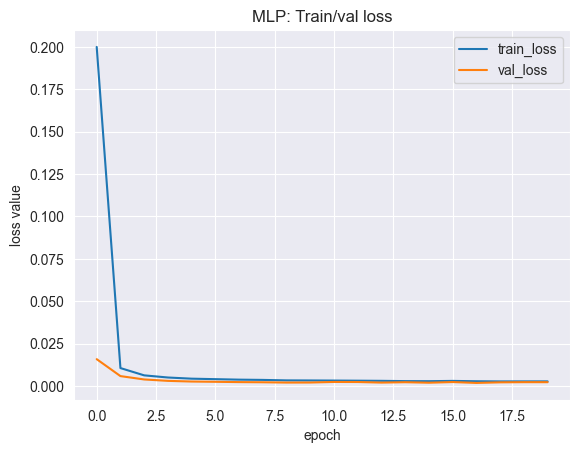

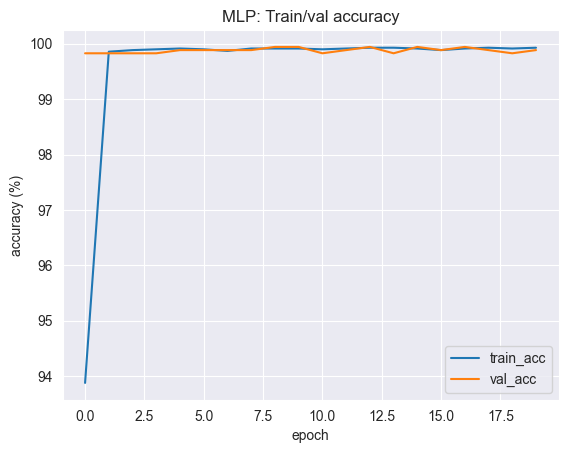

In [19]:
input_dim = len(features)

mlp_results = train_mlp_model(
    X_train_s, y_train,
    X_test_s, y_test,
    input_dim=input_dim,
    hidden_dim=32,
    n_epochs=20,
    lr=0.001
)


In [20]:
df_test = df.loc[X_test.index].copy()

print("=== LR Fairness by Race ===")
lr_fair_race = fairness_by_group(y_test, lr_results["pred"], df_test["race"])
print(lr_fair_race)

print("\n=== LR Fairness by Gender ===")
lr_fair_gender = fairness_by_group(y_test, lr_results["pred"], df_test["gender"])
print(lr_fair_gender)

LR_EO_race = equal_opportunity_diff(lr_fair_race)
LR_EO_gender = equal_opportunity_diff(lr_fair_gender)



print("\n=== MLP Fairness by Race ===")
mlp_fair_race = fairness_by_group(y_test, mlp_results["pred"], df_test["race"])
print(mlp_fair_race)

print("\n=== MLP Fairness by Gender ===")
mlp_fair_gender = fairness_by_group(y_test, mlp_results["pred"], df_test["gender"])
print(mlp_fair_gender)

MLP_EO_race   = equal_opportunity_diff(mlp_fair_race)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)


=== LR Fairness by Race ===
   FPR       FNR       TPR  TNR
0  0.0  0.000000  1.000000  1.0
1  0.0  0.011765  0.988235  1.0
2  0.0  0.000000  1.000000  1.0

=== LR Fairness by Gender ===
   FPR       FNR       TPR  TNR
0  0.0  0.005376  0.994624  1.0
1  0.0  0.000000  1.000000  1.0

=== MLP Fairness by Race ===
        FPR       FNR       TPR       TNR
0  0.000000  0.000000  1.000000  1.000000
1  0.002611  0.011765  0.988235  0.997389
2  0.000000  0.000000  1.000000  1.000000

=== MLP Fairness by Gender ===
        FPR       FNR       TPR       TNR
0  0.000000  0.005376  0.994624  1.000000
1  0.001422  0.000000  1.000000  0.998578


In [21]:
LR_EO_race   = equal_opportunity_diff(lr_fair_race)
MLP_EO_race  = equal_opportunity_diff(mlp_fair_race)

LR_EO_gender = equal_opportunity_diff(lr_fair_gender)
MLP_EO_gender = equal_opportunity_diff(mlp_fair_gender)

results_repr = {
    "world_name": "RepresentationBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

results_repr


{'world_name': 'RepresentationBias',
 'LR_accuracy': 0.9994252873563219,
 'LR_AUROC': 0.9999854553010233,
 'LR_EO_race': 0.0117647058823529,
 'LR_EO_gender': 0.005376344086021501,
 'MLP_accuracy': np.float64(0.9988505747126437),
 'MLP_AUROC': 0.9999937665575814,
 'MLP_EO_race': 0.0117647058823529,
 'MLP_EO_gender': 0.005376344086021501}

In [25]:
results_repr = {
    "world_name": "RepresentationBias",
    "LR_accuracy": lr_results["accuracy"],
    "LR_AUROC": lr_results["AUROC"],
    "LR_EO_race": LR_EO_race,
    "LR_EO_gender": LR_EO_gender,
    "MLP_accuracy": mlp_results["accuracy"],
    "MLP_AUROC": mlp_results["AUROC"],
    "MLP_EO_race": MLP_EO_race,
    "MLP_EO_gender": MLP_EO_gender,
}

json.dump(results_repr, open("results_representation.json", "w"), indent=4)
print("Saved RepresentationBias world → results_representation.json")


Saved RepresentationBias world → results_representation.json
